<a href="https://colab.research.google.com/github/JuanitaRozo/Redes-Neuronales-II/blob/main/06_MNIST_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Laboratorio F

In [8]:
from tensorflow import keras
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) =     keras.datasets.mnist.load_data()

print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba:", x_test_mnist.shape, y_test_mnist.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenamiento: (60000, 28, 28) (60000,)
Prueba: (10000, 28, 28) (10000,)


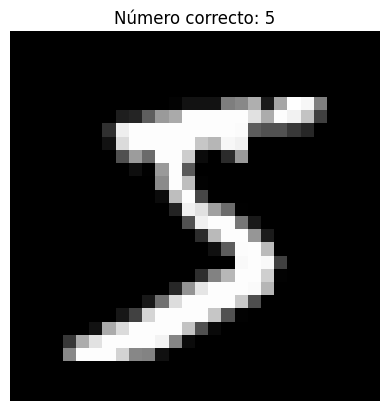

Mínimo: 0.0
Máximo: 1.0


In [9]:
import matplotlib.pyplot as plt

plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())


In [10]:
import tensorflow as tf

tf.random.set_seed(42)

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo_mnist.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9209 - loss: 0.2766 - val_accuracy: 0.9625 - val_loss: 0.1255
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9633 - loss: 0.1240 - val_accuracy: 0.9690 - val_loss: 0.1005
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9752 - loss: 0.0845 - val_accuracy: 0.9722 - val_loss: 0.0897
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0621 - val_accuracy: 0.9750 - val_loss: 0.0813
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9868 - loss: 0.0468 - val_accuracy: 0.9763 - val_loss: 0.0816


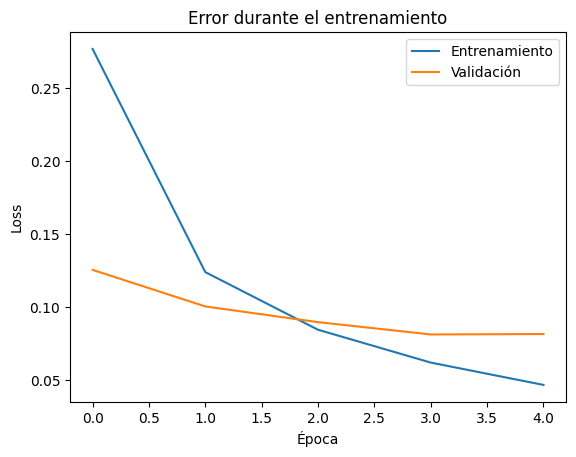

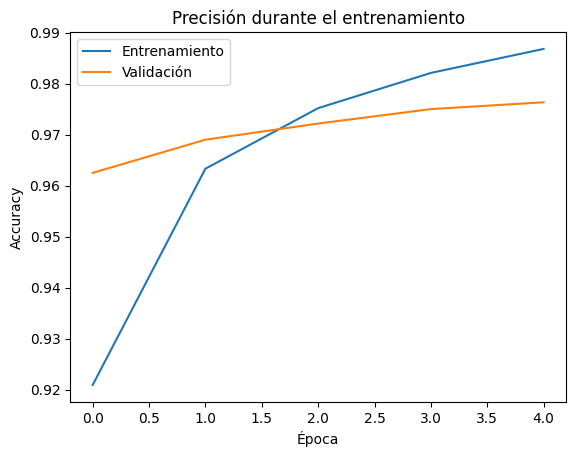

In [12]:
plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [13]:
test_loss_mnist, test_accuracy_mnist = modelo_mnist.evaluate(
    x_test_mnist,
    y_test_mnist,
    verbose=0
)

print("Error de prueba:", test_loss_mnist)
print("Accuracy de prueba:", test_accuracy_mnist)

predicciones_mnist = modelo_mnist.predict(x_test_mnist[:10], verbose=0)

for i in range(10):
    prediccion = np.argmax(predicciones_mnist[i])
    print("Imagen", i + 1, "| Real:", y_test_mnist[i], "| Predicción:", prediccion)


Error de prueba: 0.09108245372772217
Accuracy de prueba: 0.9732999801635742
Imagen 1 | Real: 7 | Predicción: 7
Imagen 2 | Real: 2 | Predicción: 2
Imagen 3 | Real: 1 | Predicción: 1
Imagen 4 | Real: 0 | Predicción: 0
Imagen 5 | Real: 4 | Predicción: 4
Imagen 6 | Real: 1 | Predicción: 1
Imagen 7 | Real: 4 | Predicción: 4
Imagen 8 | Real: 9 | Predicción: 9
Imagen 9 | Real: 5 | Predicción: 6
Imagen 10 | Real: 9 | Predicción: 9


Cantidad de errores: 267


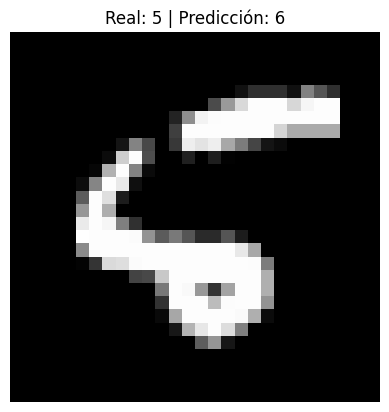

In [14]:
predicciones_todas = modelo_mnist.predict(x_test_mnist, verbose=0)
clases_predichas = np.argmax(predicciones_todas, axis=1)
errores = np.where(clases_predichas != y_test_mnist)[0]

print("Cantidad de errores:", len(errores))

indice_error = errores[0]
plt.imshow(x_test_mnist[indice_error], cmap="gray")
plt.title(
    f"Real: {y_test_mnist[indice_error]} | "
    f"Predicción: {clases_predichas[indice_error]}"
)
plt.axis("off")
plt.show()


Inicio codificacion laboratorio F

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [17]:
class RedMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.capa1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.salida = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.capa1(x)
        x = self.relu(x)
        x = self.salida(x)
        return x

modelo_pytorch = RedMNIST()
print(modelo_pytorch)


RedMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (capa1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (salida): Linear(in_features=128, out_features=10, bias=True)
)


In [18]:
criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(
    modelo_pytorch.parameters(),
    lr=0.001
)

print("Modelo, criterio y optimizador listos")


Modelo, criterio y optimizador listos


In [19]:
epochs = 3

for epoch in range(epochs):
    modelo_pytorch.train()
    error_total = 0

    for imagenes, etiquetas in train_loader:
        # 1. Limpiar gradientes anteriores
        optimizador.zero_grad()

        # 2. Forward
        salidas = modelo_pytorch(imagenes)

        # 3. Loss
        error = criterio(salidas, etiquetas)

        # 4. Backpropagation
        error.backward()

        # 5. Actualizar pesos
        optimizador.step()

        error_total += error.item()

    promedio_error = error_total / len(train_loader)
    print("Época:", epoch + 1, "- Error:", round(promedio_error, 4))


Época: 1 - Error: 0.3406
Época: 2 - Error: 0.1552
Época: 3 - Error: 0.1096


In [20]:
modelo_pytorch.eval()
correctas = 0
total = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        salidas = modelo_pytorch(imagenes)
        _, predicciones = torch.max(salidas, 1)
        total += etiquetas.size(0)
        correctas += (predicciones == etiquetas).sum().item()

accuracy_pytorch = correctas / total
print("Accuracy en prueba:", accuracy_pytorch)


Accuracy en prueba: 0.9689


Número real: 7
Número predicho: 7


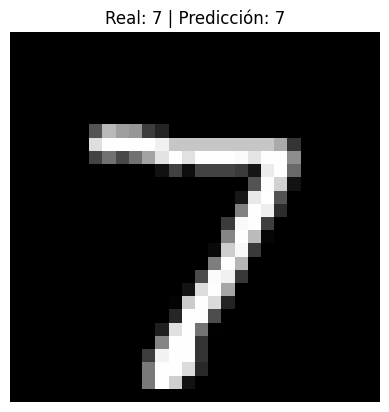

In [21]:
imagen, etiqueta_real = test_dataset[0]
entrada = imagen.unsqueeze(0)

modelo_pytorch.eval()
with torch.no_grad():
    salida = modelo_pytorch(entrada)
    prediccion = torch.argmax(salida, dim=1).item()

print("Número real:", etiqueta_real)
print("Número predicho:", prediccion)

plt.imshow(imagen.squeeze(), cmap="gray")
plt.title(f"Real: {etiqueta_real} | Predicción: {prediccion}")
plt.axis("off")
plt.show()
